# NMPC

Step 9.1. The Phase 5 model in CasADi for acados (`ackermann_nmpc/model.py`): path coordinates
of the rear axle, the two /drive commands as states and their rates as inputs, friction
`mu_scale` and path curvature as parameters. Checked here against `scripts/vehicle_model.py`.

Step 9.2. The NMPC (`ackermann_nmpc/ocp.py`) in closed loop on the Phase 5 car, against the
Pure Pursuit of Phase 7, on floors with less grip.

Step 9.3. The C++ node (`ackermann_nmpc/src/nmpc_node.cpp`) in Gazebo, on the localization of
the car.

In [1]:
import os
import sys
import tempfile
sys.path.append('../scripts')
sys.path.append('../ros2_ws/src/ackermann_nmpc')
sys.path.append('../ros2_ws/src/ackermann_control')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from acados_template import AcadosOcpSolver, AcadosSim, AcadosSimSolver
import bagtools as bt
import vehicle_model as vm
from ackermann_control.pure_pursuit import lateral_error, load_track, nearest, steering
from ackermann_nmpc.model import TAU_U, forces, path_model
from ackermann_nmpc.ocp import DT, N, ocp

plt.rcParams['figure.dpi'] = 72
p = yaml.safe_load(open('../ros2_ws/src/ackermann_description/config/vehicle_params.yaml'))['/**']['ros__parameters']

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Forces

Both at 10000 random states, over and past the range of the Phase 5 runs.

In [2]:
rng = np.random.default_rng(0)
n = 10000
X = np.c_[rng.uniform(0.1, 1.5, n), rng.uniform(-0.6, 0.6, n), rng.uniform(-5, 5, n),
          rng.uniform(-0.5, 0.5, n), rng.uniform(0, 1.3, n)]
ref = np.array([vm.forces(x[:4], x[4]) for x in X])
ours = np.array([np.array([float(v) for v in forces(p, *x, 1.0)]) for x in X])
err = np.abs(ours - ref).max(axis=0)
print(f'max |difference|: fx {err[0]:.1e} N, fy {err[1]:.1e} N, mz {err[2]:.1e} N m '
      f'(fy up to {np.abs(ref[:, 1]).max():.1f} N)')

max |difference|: fx 1.4e-07 N, fy 1.4e-07 N, mz 1.3e-08 N m (fy up to 6.4 N)


## Integration

The /drive commands of val_drift (0.9 m/s at full lock, the 1.3 m/s donut, 0.6 m/s) from 0.3 m/s:
the acados integrator (explicit RK4, 1 ms steps) against the numpy RK4 of the notebooks, same
1 ms. Once along a straight path, where s, n and e_psi are x, y and yaw of the rear axle, once
along a circle of 5 m radius turning left, mapped back to x, y.

In [3]:
run = pd.read_parquet('../data/sysid/val_drift.parquet')
run = run[run['cmd_speed'].ffill() > 0].reset_index(drop=True)
t = run['t'].to_numpy()
d_cmd = np.interp(run['cmd_steer'].ffill(), vm.CMD, vm.DEL)
u_cmd = run['cmd_speed'].ffill().to_numpy()
dt = 0.02
steps = int((t[-1] - t[0]) / dt)
cmd = [np.searchsorted(t, t[0] + k * dt, side='right') - 1 for k in range(steps)]


def deriv(x, dc, uc):
    X, Y, psi, vx, vy, r, d, u = x
    fx, fy, mz = vm.forces((vx, vy, r, d), u)
    return np.array([vx * np.cos(psi) - vy * np.sin(psi), vx * np.sin(psi) + vy * np.cos(psi), r,
                     fx / vm.M + vy * r, fy / vm.M - vx * r, mz / vm.IZ, (dc - d) / vm.TAU, (uc - u) / TAU_U])


x = np.array([p['lr'], 0, 0, 0.3, 0, 0, d_cmd[0], 0.3])     # CG, rear axle on the origin
ref = []
for i in cmd:
    h = dt / 20
    for _ in range(20):
        k1 = deriv(x, d_cmd[i], u_cmd[i])
        k2 = deriv(x + h / 2 * k1, d_cmd[i], u_cmd[i])
        k3 = deriv(x + h / 2 * k2, d_cmd[i], u_cmd[i])
        k4 = deriv(x + h * k3, d_cmd[i], u_cmd[i])
        x = x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    ref.append(x)
ref = np.array(ref)
rear_x, rear_y = ref[:, 0] - p['lr'] * np.cos(ref[:, 2]), ref[:, 1] - p['lr'] * np.sin(ref[:, 2])


def acados_run(kappa):
    sim = AcadosSim()
    sim.model = path_model(p)
    sim.parameter_values = np.array([1.0, kappa])
    sim.solver_options.T = dt
    sim.solver_options.integrator_type = 'ERK'
    sim.solver_options.num_stages = 4
    sim.solver_options.num_steps = 20
    sim.code_gen_options.code_export_directory = tempfile.mkdtemp()
    sim.code_gen_options.json_file = os.path.join(sim.code_gen_options.code_export_directory, 'sim.json')
    solver = AcadosSimSolver(sim, verbose=False)
    x = np.array([0, 0, 0, 0.3, 0, 0, d_cmd[0], 0.3, d_cmd[0], u_cmd[0]])
    out = []
    for i in cmd:
        x[8:] = d_cmd[i], u_cmd[i]
        x = solver.simulate(x=x, u=np.zeros(2))
        out.append(x)
    return np.array(out)


rows = []
for kappa in [0.0, 0.2]:
    s, n, e_psi = acados_run(kappa)[:, :3].T
    if kappa == 0:
        X, Y, psi = s, n, e_psi
    else:
        R, a = 1 / kappa, s * kappa     # circle centred at (0, R), from the origin heading +x
        X, Y, psi = R * np.sin(a) - n * np.sin(a), R - R * np.cos(a) + n * np.cos(a), a + e_psi
    rows.append({'path': 'straight' if kappa == 0 else 'circle R 5 m',
                 'position [m]': np.hypot(X - rear_x, Y - rear_y).max(),
                 'heading [rad]': np.abs(psi - ref[:, 2]).max()})
print(f'{steps * dt:.1f} s, yaw rate up to {ref[:, 5].max():.2f} rad/s, max |difference|:')
pd.DataFrame(rows)

16.0 s, yaw rate up to 5.49 rad/s, max |difference|:


,path,position [m],heading [rad]
0,straight,8.934193e-08,1.495347e-07
1,circle R 5 m,8.934252e-08,1.495493e-07


The CasADi model is the Phase 5 model: forces within 1.4e-7 N (the smoothing of the slip at
zero), and 16 s of val_drift through the acados integrator within 1e-7 m of the numpy one, along
a straight path and along a circle.

## Closed loop

The OCP: 1 s ahead in 25 stages, 10 of 20 ms then 15 of 53 ms, solved every 20 ms. Cost on the offset n (5 cm), the heading error (0.1 rad),
the speed against the profile (0.3 m/s) and the command rates (0.5 rad/s2, 0.5 m/s3 as rates of
the commands). Commands within the steering map and 0-1.2 m/s, rates within 4.36 rad/s and
5 m/s2; soft |n| < 0.3 m and vx > 0.3 m/s, where the tire model holds. No bound on the slip.
Integrator: implicit Gauss-Legendre, one step per stage, the model being stiff at low speed.
Solver: one Gauss-Newton SQP iteration per control step with a merit line search, warm started
from the previous solution.

The car: the Phase 5 model (`vehicle_model.forces`, friction scaled as in sim_car) and the measured wheel
speed lags (15-45 ms, the NMPC assumes 30), numpy RK4 at 1 ms, commands every 20 ms. Both
controllers get the true state, no delay: the sim of step 9.3 adds the estimator and the network.

The speed profile of the track is recomputed for each floor as in `make_track.py`, with the
lateral limit a fraction f of the rear axle grip on it (0.276 g times mu_scale) and half of that
along the track. Pure Pursuit is the Phase 7 one: rear axle, lookahead 0.3 + 0.4 v.

In [4]:
track = load_track('../ros2_ws/src/ackermann_bringup/maps/room_track.csv')
L_TRACK = track['s'][-1] + np.hypot(track['x'][0] - track['x'][-1], track['y'][0] - track['y'][-1])
DS = np.diff(np.r_[track['s'], L_TRACK])
A_GRIP = 0.276 * 9.81


def profile(a_lat, a_long):
    # as make_track.py: lateral limit, then speeding up and braking, twice around the loop
    v = np.minimum(p['v_max'], np.sqrt(a_lat / np.maximum(np.abs(track['kappa']), 1e-9)))
    n = len(v)
    for _ in range(2):
        for i in range(1, 2 * n):
            v[i % n] = min(v[i % n], np.sqrt(v[(i - 1) % n] ** 2 + 2 * a_long * DS[(i - 1) % n]))
        for i in range(2 * n - 2, -1, -1):
            v[i % n] = min(v[i % n], np.sqrt(v[(i + 1) % n] ** 2 + 2 * a_long * DS[i % n]))
    return v


def at(s, values):
    return values[np.searchsorted(track['s'], np.mod(s, L_TRACK), side='right') - 1]


def to_path(x, y, yaw, s_prev):
    # rear axle onto the line: nearest point after the previous s, then along and across it
    i = np.searchsorted(track['s'], np.mod(s_prev, L_TRACK), side='right') - 1
    idx = (i + np.arange(-10, 30)) % len(track['s'])
    k = idx[np.argmin(np.hypot(track['x'][idx] - x, track['y'][idx] - y))]
    dx, dy, yaw_k = x - track['x'][k], y - track['y'][k], track['yaw'][k]
    s = track['s'][k] + dx * np.cos(yaw_k) + dy * np.sin(yaw_k)
    s += L_TRACK * np.round((s_prev - s) / L_TRACK)     # keep counting laps
    return s, -dx * np.sin(yaw_k) + dy * np.cos(yaw_k), np.angle(np.exp(1j * (yaw - yaw_k)))


def car_deriv(x, mu, d_cmd, u_cmd):
    X, Y, psi, vx, vy, r, d, u = x
    fx, fy, mz = vm.forces((vx, vy, r, d), u, mu)
    tau_u = np.interp(abs(u_cmd), p['speed_lag_v'], p['speed_lag'])
    return np.array([vx * np.cos(psi) - vy * np.sin(psi), vx * np.sin(psi) + vy * np.cos(psi), r,
                     fx / vm.M + vy * r, fy / vm.M - vx * r, mz / vm.IZ, (d_cmd - d) / vm.TAU, (u_cmd - u) / tau_u])


def make_solver(rti=False):
    o = ocp(p, tempfile.mkdtemp())
    if rti:
        o.solver_options.nlp_solver_type = 'SQP_RTI'
        o.solver_options.globalization = 'FIXED_STEP'
    return AcadosOcpSolver(o, verbose=False)


def simulate(ctrl, mu, v_ref, solver=None, laps=3, dt=DT):
    # 3 laps from the start of the line at 0.3 m/s; stops 0.5 m off the line as the Phase 7 node
    x = np.array([track['x'][0] + p['lr'] * np.cos(track['yaw'][0]), track['y'][0] + p['lr'] * np.sin(track['yaw'][0]),
                  track['yaw'][0], 0.3, 0.0, 0.0, 0.0, 0.3])
    cmd, s_prev, i_pp = np.array([0.0, 0.3]), 0.0, None
    log, times, qp_fails, lost = [], [], 0, False
    for k in range(int(laps * 1.5 * np.sum(DS / v_ref) / dt)):
        xr, yr = x[0] - p['lr'] * np.cos(x[2]), x[1] - p['lr'] * np.sin(x[2])
        s, n, e_psi = to_path(xr, yr, x[2], s_prev)
        s_prev = s
        lost = abs(n) > 0.5
        if lost or s > laps * L_TRACK:
            break
        if ctrl == 'nmpc':
            x0 = np.r_[s, n, e_psi, x[3:8], cmd]
            if k == 0:
                for j in range(N + 1):
                    solver.set(j, 'x', x0)
                    if j < N:
                        solver.set(j, 'u', np.zeros(2))
            for j in range(N + 1):
                sj = solver.get(j, 'x')[0]
                solver.set(j, 'p', np.array([mu, at(sj, track['kappa'])]))
                solver.set(j, 'yref', np.array([0, 0, at(sj, v_ref), 0, 0])[:5 if j < N else 3])
            solver.set(0, 'lbx', x0)
            solver.set(0, 'ubx', x0)
            for _ in range(10 if k == 0 else 1):
                status = solver.solve()
            qp_fails += status not in (0, 2)     # 2: iteration limit, the normal case with one
            times.append(solver.get_stats('time_tot'))
            cmd = solver.get(1, 'x')[8:10]
        else:
            i_pp = nearest(track, xr, yr, i_pp)
            v = v_ref[i_pp]
            delta = steering(track, i_pp, xr, yr, x[2], 0.3 + 0.4 * v, vm.L)
            cmd = np.array([np.interp(np.interp(delta, vm.DEL, vm.CMD), vm.CMD, vm.DEL), v])
        steps = round(dt / 0.001)     # the car at 1 ms: stiff at low speed
        for _ in range(steps):
            h = dt / steps
            k1 = car_deriv(x, mu, *cmd)
            k2 = car_deriv(x + h / 2 * k1, mu, *cmd)
            k3 = car_deriv(x + h / 2 * k2, mu, *cmd)
            k4 = car_deriv(x + h * k3, mu, *cmd)
            x = x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        log.append((k * dt, s, n, np.degrees(np.arctan2(x[4] - p['lr'] * x[5], x[3])), x[3], *cmd))
    log = pd.DataFrame(log, columns=['t', 's', 'n', 'rear_slip', 'vx', 'd_cmd', 'u_cmd'])
    w = log['t'] > 1.0
    return log, {'laps': log['s'].iloc[-1] / L_TRACK, 'lost': lost,
                 'time [s]': np.nan if lost else log['t'].iloc[-1],
                 'error rms [cm]': np.sqrt(np.mean(log['n'][w] ** 2)) * 100,
                 'error max [cm]': np.abs(log['n'][w]).max() * 100,
                 'rear slip max [deg]': np.abs(log['rear_slip'][w]).max(),
                 'solve mean [ms]': np.mean(times) * 1e3 if times else np.nan,
                 'solve max [ms]': np.max(times) * 1e3 if times else np.nan, 'qp fails': qp_fails}


solver = make_solver()

### On the tiles

The Phase 7 speed profile (0.77-1.0 m/s), full friction.

In [5]:
rows = []
for ctrl in ['pp', 'nmpc']:
    _, res = simulate(ctrl, 1.0, track['v'], solver)
    rows.append({'controller': ctrl, **res})
pd.DataFrame(rows).round(2)

,controller,laps,lost,time [s],error rms [cm],error max [cm],rear slip max [deg],solve mean [ms],solve max [ms],qp fails
0,pp,3.0,False,31.00,3.19,6.83,1.03,NaN,NaN,0
1,nmpc,3.0,False,30.36,1.55,3.07,0.85,0.51,0.86,0


### Less grip

mu_scale 0.35 and 0.25, speed profile at 60 to 120% of the grip of the floor.

In [6]:
rows, logs = [], {}
for mu in [0.35, 0.25]:
    for f in [0.6, 0.8, 1.0, 1.2]:
        v_ref = profile(f * mu * A_GRIP, 0.5 * f * mu * A_GRIP)
        for ctrl in ['pp', 'nmpc']:
            logs[ctrl, mu, f], res = simulate(ctrl, mu, v_ref, solver)
            rows.append({'mu_scale': mu, 'f': f, 'corner [m/s]': v_ref.min(), 'controller': ctrl, **res})
grid = pd.DataFrame(rows)
grid.round(2)

,mu_scale,f,corner [m/s],controller,laps,lost,time [s],error rms [cm],error max [cm],rear slip max [deg],solve mean [ms],solve max [ms],qp fails
0,0.35,0.6,0.58,pp,3.00,False,40.08,2.15,4.57,0.80,NaN,NaN,0
1,0.35,0.6,0.58,nmpc,3.00,False,39.92,1.30,2.38,2.73,0.52,1.29,0
2,0.35,0.8,0.67,pp,3.00,False,35.06,3.24,7.80,1.74,NaN,NaN,0
3,0.35,0.8,0.67,nmpc,3.00,False,35.48,1.18,2.44,7.18,0.53,1.26,0
4,0.35,1.0,0.75,pp,3.00,False,31.80,4.95,12.84,5.62,NaN,NaN,0
5,0.35,1.0,0.75,nmpc,3.00,False,33.52,1.26,2.87,10.55,0.54,1.27,0
6,0.35,1.2,0.83,pp,3.00,False,29.40,5.80,14.75,10.42,NaN,NaN,0
7,0.35,1.2,0.83,nmpc,3.00,False,32.58,1.68,3.54,14.19,0.55,0.98,0
8,0.25,0.6,0.49,pp,3.00,False,47.28,1.74,3.66,0.81,NaN,NaN,0
9,0.25,0.6,0.49,nmpc,3.00,False,46.34,1.11,2.08,3.89,0.51,1.29,0


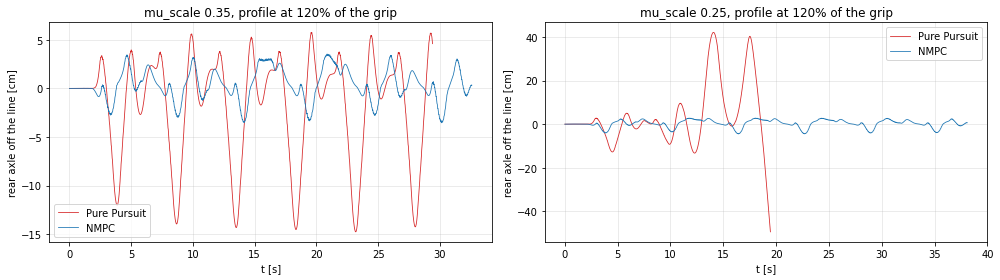

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, (mu, f) in zip(ax, [(0.35, 1.2), (0.25, 1.2)]):
    for ctrl, c in [('pp', 'C3'), ('nmpc', 'C0')]:
        log = logs[ctrl, mu, f]
        a.plot(log['t'], log['n'] * 100, c, lw=0.8, label='Pure Pursuit' if ctrl == 'pp' else 'NMPC')
    a.set_title(f'mu_scale {mu}, profile at {f:.0%} of the grip')
    a.set_xlabel('t [s]')
    a.set_ylabel('rear axle off the line [cm]')
    a.grid(alpha=0.3)
    a.legend()
plt.tight_layout()
plt.show()

### The solver

The same NMPC with the plain real time iteration of acados (one full Gauss-Newton step per
control step, no line search), at the edge of the grip.

In [8]:
rti = make_solver(rti=True)
rows = []
for mu, f in [(0.35, 1.0), (0.25, 1.0)]:
    v_ref = profile(f * mu * A_GRIP, 0.5 * f * mu * A_GRIP)
    for name, sv in [('RTI', rti), ('line search', solver)]:
        log, res = simulate('nmpc', mu, v_ref, sv)
        chatter = np.mean(np.abs(np.diff(log['d_cmd'], 2)) > 0.05)
        rows.append({'mu_scale': mu, 'f': f, 'solver': name, **res, 'steering chatter': chatter})
pd.DataFrame(rows).round(3)

,mu_scale,f,solver,laps,lost,time [s],error rms [cm],error max [cm],rear slip max [deg],solve mean [ms],solve max [ms],qp fails,steering chatter
0,0.35,1.0,RTI,3.000,False,39.34,1.934,7.310,12.468,0.384,0.944,0,0.252
1,0.35,1.0,line search,2.999,False,33.44,1.244,2.914,10.405,0.530,1.257,0,0.000
2,0.25,1.0,RTI,3.000,False,43.16,2.361,9.286,12.459,0.418,0.912,0,0.383
3,0.25,1.0,line search,3.000,False,38.86,1.248,2.698,10.177,0.551,1.286,0,0.000


### Result

On the tiles at the Phase 7 speeds the NMPC keeps the rear axle 1.6 cm rms from the line (3.1 at
worst) against 3.2 (6.8) for Pure Pursuit, both with the true state and no delay.

With less grip and the speed profile at a fraction of it, the NMPC stays at 1.1-1.8 cm rms (2.1-4.5
at worst) from 60 to 120% of the grip on both floors. Pure Pursuit goes from 1.7-2.2 to 5-6 cm and
spins at 120% on mu_scale 0.25. Up to 80% the two take the same time. At and past the grip the NMPC
lets the rear slip 10-17 deg and gives up time to hold the line: 3-5% at 100%, 11% at 120% (32.6 s
against 29.4 for three laps on mu_scale 0.35, where Pure Pursuit keeps the speed and runs wide).

The line search matters: with the plain real time iteration of acados (the full Gauss-Newton step)
the steering command chatters at the limit, on 25-38% of the steps, and the error at worst triples
(7-9 cm). One iteration with a merit line search, same cost, fixes it. Solve time 0.5 ms on average
and 1.3 at worst on the desktop.

## Gazebo

The node runs the solver generated by acados from `ocp.py` at 50 Hz. It measures the rear axle
pose (AMCL on the EKF, map -> base_footprint), vx and the yaw rate (EKF) and the wheel speed;
the lateral velocity and the steering angle are not measured and come from the previous solve,
one step ahead. The session of `simulation.ipynb`, 3 laps on the speed profile of the tiles, the
NMPC told the friction of the floor: at mu_scale 0.35 the profile asks ~105% of the grip, at 0.25
~150%. Then the tight line of step 9.4 (corners of 0.4 m, 1.04-1.2 m/s) on the tiles. Pure Pursuit
from the Phase 8 runs and the same session. Errors against /ground_truth.

In [9]:
rows = {}
for name in ['sim_pp_full', 'sim_nmpc_full', 'sim_pp_mu0.35', 'sim_nmpc_mu0.35', 'sim_pp_mu0.25', 'sim_nmpc_mu0.25',
             'sim_pp_tight', 'sim_nmpc_tight']:
    track = load_track('../ros2_ws/src/ackermann_bringup/maps/' + ('room_tight' if 'tight' in name else 'room_track') + '.csv')
    d = bt.load(f'../data/{name}_parquet')
    js = d['joint_states']
    moving = js['t'][js[['wl', 'wr']].abs().max(axis=1) > 1.0]
    g = d['ground_truth']
    g = g[(g['t'] > moving.iloc[0] + 1.0) & (g['t'] < moving.iloc[-1])]
    idx, e, i = [], [], None
    for x, y in zip(g['x'], g['y']):
        i = nearest(track, x, y, i)
        idx.append(i)
        e.append(lateral_error(track, i, x, y))
    idx, e = np.array(idx), np.array(e) * 100
    n = len(track['s'])
    laps = np.diff(g['t'].to_numpy()[1:][(idx[:-1] > 3 * n // 4) & (idx[1:] < n // 4)])
    t, X, Y = bt.map_pose(d)
    stamp = np.interp(t, d['odometry_filtered']['t'], d['odometry_filtered']['stamp'])
    w = (t > moving.iloc[0] + 1.0) & (t < moving.iloc[-1])
    gx = np.interp(stamp[w], d['ground_truth']['stamp'], d['ground_truth']['x'])
    gy = np.interp(stamp[w], d['ground_truth']['stamp'], d['ground_truth']['y'])
    fast = g[g['vx'] > 0.3]
    row = {'driven [s]': moving.iloc[-1] - moving.iloc[0], 'laps [s]': ', '.join(f'{x:.1f}' for x in laps),
           'true error rms [cm]': np.sqrt(np.mean(e ** 2)), 'true error max [cm]': np.abs(e).max(),
           'rear slip max [deg]': np.degrees(np.abs(np.arctan2(fast['vy'], fast['vx']))).max(),
           'localization rms [cm]': np.sqrt(np.mean((np.hypot(X[w] - gx, Y[w] - gy) * 100) ** 2))}
    if 'nmpc_solve_time' in d:
        ms = d['nmpc_solve_time']['ms'][1:]     # the first call runs 10 iterations
        row.update({'solve mean [ms]': ms.mean(), 'solve 99% [ms]': ms.quantile(0.99), 'solve max [ms]': ms.max()})
    rows[name] = row
track = load_track('../ros2_ws/src/ackermann_bringup/maps/room_track.csv')
pd.DataFrame.from_dict(rows, orient='index').round(2)

,driven [s],laps [s],true error rms [cm],true error max [cm],rear slip max [deg],localization rms [cm],solve mean [ms],solve 99% [ms],solve max [ms]
sim_pp_full,30.84,"10.1, 10.2",4.65,11.11,3.53,5.71,NaN,NaN,NaN
sim_nmpc_full,30.66,"10.0, 9.9",5.62,12.09,2.78,6.01,0.63,0.89,2.21
sim_pp_mu0.35,30.92,"10.1, 10.1",7.56,28.14,13.19,13.56,NaN,NaN,NaN
sim_nmpc_mu0.35,32.64,"10.7, 10.5",3.34,7.92,17.27,6.37,0.68,1.28,1.70
sim_pp_mu0.25,6.24,,20.45,41.80,62.32,66.02,NaN,NaN,NaN
sim_nmpc_mu0.25,34.02,"11.2, 11.0",6.65,17.50,28.56,18.40,0.68,1.08,1.46
sim_pp_tight,23.78,"7.9, 7.8",7.99,20.71,11.86,7.81,NaN,NaN,NaN
sim_nmpc_tight,28.04,"9.0, 9.1",4.78,11.97,2.26,4.76,0.68,0.96,1.15


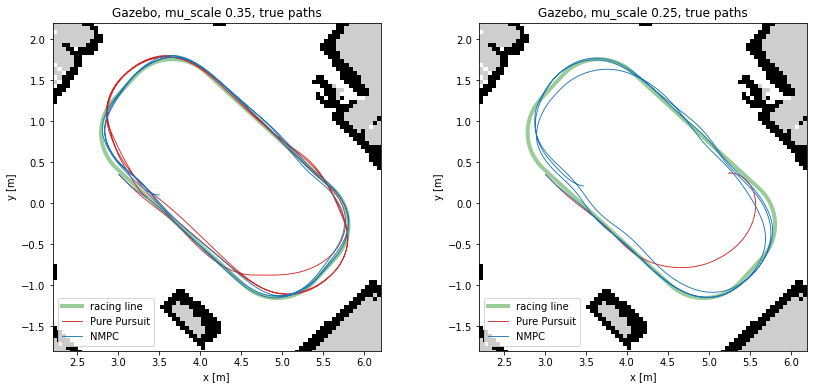

In [10]:
room = yaml.safe_load(open('../ros2_ws/src/ackermann_bringup/maps/room.yaml'))
room_img = np.array(Image.open('../ros2_ws/src/ackermann_bringup/maps/room.pgm'))
res, (x0, y0) = room['resolution'], room['origin'][:2]
extent = [x0, x0 + room_img.shape[1] * res, y0, y0 + room_img.shape[0] * res]
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
for a, mu in zip(ax, ['0.35', '0.25']):
    a.imshow(room_img, cmap='gray', extent=extent)
    a.plot(track['x'], track['y'], 'g', lw=4, alpha=0.4, label='racing line')
    for name, c, label in [(f'sim_pp_mu{mu}', 'C3', 'Pure Pursuit'), (f'sim_nmpc_mu{mu}', 'C0', 'NMPC')]:
        g = bt.load(f'../data/{name}_parquet')['ground_truth']
        a.plot(g['x'], g['y'], c, lw=0.9, label=label)
    a.set_xlim(2.2, 6.2)
    a.set_ylim(-1.8, 2.2)
    a.set_title(f'Gazebo, mu_scale {mu}, true paths')
    a.set_xlabel('x [m]')
    a.set_ylabel('y [m]')
    a.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Result

With the localization of the car in the loop the NMPC is no better than Pure Pursuit on the tiles
(5.6 against 4.7 cm rms from the line): both follow a pose ~6 cm rms off the truth, and the
controller no longer makes the difference. It does when the grip runs out. At mu_scale 0.35 (~105%
of the grip) 3.3 cm rms and 8 at worst against 7.6 and 28; at 0.25 (~150%), where Pure Pursuit
spins in the first lap, the NMPC drives the three laps 10% slower, 6.7 cm rms from the line, the
rear sliding up to 29 deg. The localization degrades as the car slides, to 6-18 cm rms. On the tight
line at the speed of the grip of the tiles, 4.8 cm rms against 8.0, 15% slower. Solve time 0.6-0.7
ms on average, 2.2 at worst.